## **Unit 4 — Global GDP and Population Analysis**

**Task A:** Correlation between mean population and mean per‑capita GDP of each country (2001–2021)  
**Task B:** Linear regression — mean population (independent variable) vs mean per‑capita GDP (dependent variable)

Data sources: `Unit04_Global_GDP.csv` (World Bank, GDP current US$) and `Unit04_Global_Population.csv` (World Bank, total population).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (8, 6)

### **1. Load the data**

In [4]:
gdp_raw = pd.read_csv('Unit04 Global_GDP.csv')
pop_raw = pd.read_csv('Unit04 Global_Population.csv')

print('GDP file shape:', gdp_raw.shape)
print('Population file shape:', pop_raw.shape)
print(gdp_raw.head())

print(pop_raw.head())

GDP file shape: (266, 65)
Population file shape: (272, 66)
                  Country Name Country Code     Indicator Name  \
0                        Aruba          ABW  GDP (current US$)   
1  Africa Eastern and Southern          AFE  GDP (current US$)   
2                  Afghanistan          AFG  GDP (current US$)   
3   Africa Western and Central          AFW  GDP (current US$)   
4                       Angola          AGO  GDP (current US$)   

   Indicator Code              1960              1961              1962  \
0  NY.GDP.MKTP.CD               NaN               NaN               NaN   
1  NY.GDP.MKTP.CD 19,299,444,453.00 19,709,535,909.00 21,478,715,486.00   
2  NY.GDP.MKTP.CD    537,777,811.10    548,888,895.60    546,666,677.80   
3  NY.GDP.MKTP.CD 10,404,280,784.00 11,128,050,589.00 11,943,353,288.00   
4  NY.GDP.MKTP.CD               NaN               NaN               NaN   

               1963              1964              1965  ...  \
0               NaN          

### **2. Initial inspection**

Both files are in World Bank "wide" format: one row per country/region, one column per year. A quick look shows issues that need to be handled before any analysis:

1. **Aggregate rows.** Besides individual countries, the files also contain regional/income-group aggregates such as *World*, *Arab World*, *High income*, *Euro area*, etc. These are not countries and must be excluded, otherwise they would distort the correlation and regression (e.g. "World" population is the sum of every country's population).
2. **Missing values.** Missing entries are encoded as the string `'..'` (not blank/NaN), so pandas reads the year columns as text (`object`/`str`) instead of numbers. These need to be converted to numeric, turning `'..'` into proper `NaN` values.
3. **Missing 2021 GDP.** The GDP file only goes up to **2020** (no 2021 column exists at all), while the population file goes up to **2021**. This is itself a "missing value" situation — the entire year 2021 is missing for GDP. We handle it by computing the *mean per‑capita GDP* over the years that are actually available (2001–2020), while the *mean population* is computed over the full requested 2001–2021 window (population data is complete for that range).

In [5]:
# World Bank aggregate codes (regions / income groups) - these are not countries and are excluded
AGGREGATE_CODES = {
    'AFE','AFW','ARB','CEB','CSS','EAP','EAR','EAS','ECA','ECS','EMU','EUU','FCS',
    'HIC','HPC','IBD','IBT','IDA','IDB','IDX','INX','LAC','LCN','LDC','LIC','LMC',
    'LMY','LTE','MEA','MIC','MNA','NAC','OED','OSS','PRE','PSS','PST','SAS','SSA',
    'SSF','SST','TEA','TEC','TLA','TMN','TSA','TSS','UMC','WLD'
}

print(f'Rows removed as aggregates from GDP file: {gdp_raw["Country Code"].isin(AGGREGATE_CODES).sum()}')
print(f'Rows removed as aggregates from Population file: {pop_raw["Country Code"].isin(AGGREGATE_CODES).sum()}')

Rows removed as aggregates from GDP file: 49
Rows removed as aggregates from Population file: 49


### **3. Pre-processing**

Steps:
1. Drop aggregate rows using the code list above.
2. Keep only the `Country Name`, `Country Code` and the relevant year columns.
3. Convert year columns to numeric, coercing the `'..'` placeholder to `NaN`.
4. Compute **mean population per country (2001–2021)**, ignoring missing years.
5. Compute **per‑capita GDP for every country/year** (GDP ÷ Population) over the years both datasets have in common (2001–2020), then take the **mean per‑capita GDP per country** across those years, ignoring missing years.
6. Merge the two summaries on `Country Code`, and drop any country that ends up with no valid value for either variable (e.g. very small territories with no GDP or population records at all).

In [6]:
GDP_YEARS = [str(y) for y in range(2001, 2021)]   # 2001-2020 (GDP file has no 2021 column)
POP_YEARS = [str(y) for y in range(2001, 2022)]   # 2001-2021

gdp_c = gdp_raw.loc[~gdp_raw['Country Code'].isin(AGGREGATE_CODES),
                     ['Country Name', 'Country Code'] + GDP_YEARS].copy()
pop_c = pop_raw.loc[~pop_raw['Country Code'].isin(AGGREGATE_CODES),
                     ['Country Name', 'Country Code'] + POP_YEARS].copy()

# Convert year columns to numeric; '..' (and blanks) become NaN
gdp_c[GDP_YEARS] = gdp_c[GDP_YEARS].apply(pd.to_numeric, errors='coerce')
pop_c[POP_YEARS] = pop_c[POP_YEARS].apply(pd.to_numeric, errors='coerce')

print('Countries in GDP table:', gdp_c.shape[0])
print('Countries in Population table:', pop_c.shape[0])

Countries in GDP table: 217
Countries in Population table: 223


In [7]:
# Mean population per country, 2001-2021 (missing years ignored)
pop_c['mean_population'] = pop_c[POP_YEARS].mean(axis=1, skipna=True)
pop_summary = pop_c[['Country Code', 'Country Name', 'mean_population']].dropna(subset=['mean_population'])

pop_summary.sort_values('mean_population', ascending=False).head()

,Country Code,Country Name,mean_population
47,CHN,China,"1,347,101,493.43"
112,IND,India,"1,243,656,077.86"
254,USA,United States,"310,270,157.43"
113,IDN,Indonesia,"245,360,013.95"
30,BRA,Brazil,"196,892,670.29"


In [8]:
# Per-capita GDP for each country/year (2001-2020), then averaged per country
gdp_long = gdp_c.melt(id_vars=['Country Name', 'Country Code'], value_vars=GDP_YEARS,
                       var_name='Year', value_name='GDP')
pop_long = pop_c.melt(id_vars=['Country Name', 'Country Code'], value_vars=GDP_YEARS,
                       var_name='Year', value_name='Population')

merged_yearly = pd.merge(gdp_long, pop_long, on=['Country Code', 'Country Name', 'Year'])
merged_yearly['GDP_per_capita'] = merged_yearly['GDP'] / merged_yearly['Population']

# Drop year-country observations where GDP or Population (and hence per-capita GDP) is missing
merged_yearly = merged_yearly.dropna(subset=['GDP_per_capita'])

gdp_pc_summary = (merged_yearly.groupby(['Country Code', 'Country Name'])['GDP_per_capita']
                   .mean().reset_index()
                   .rename(columns={'GDP_per_capita': 'mean_gdp_per_capita'}))

gdp_pc_summary.sort_values('mean_gdp_per_capita', ascending=False).head()

,Country Code,Country Name,mean_gdp_per_capita
119,MCO,Monaco,"152,610.10"
111,LIE,Liechtenstein,"138,115.29"
115,LUX,Luxembourg,"100,267.39"
24,BMU,Bermuda,"94,780.32"
47,CYM,Cayman Islands,"79,772.73"


In [9]:
# Combine into one analysis-ready table, one row per country
df = pd.merge(pop_summary, gdp_pc_summary, on=['Country Code', 'Country Name'], how='inner')
df = df.dropna(subset=['mean_population', 'mean_gdp_per_capita']).reset_index(drop=True)

print(f'Final number of countries with complete data: {len(df)}')
df.describe()

Final number of countries with complete data: 213


,mean_population,mean_gdp_per_capita
count,213.00,213.00
mean,"32,694,588.68","15,659.53"
std,"129,960,895.25","22,875.37"
min,"10,236.90",209.77
25%,"855,216.29","1,807.98"
50%,"6,207,085.90","5,484.68"
75%,"21,153,439.29","20,515.50"
max,"1,347,101,493.43","152,610.10"


In [10]:
df.sort_values('mean_gdp_per_capita', ascending=False).head(10)

,Country Code,Country Name,mean_population,mean_gdp_per_capita
127,MCO,Monaco,"36,092.81","152,610.10"
111,LIE,Liechtenstein,"36,200.71","138,115.29"
113,LUX,Luxembourg,"528,845.29","100,267.39"
22,BMU,Bermuda,"64,348.95","94,780.32"
36,CYM,Cayman Islands,"56,572.86","79,772.73"
144,NOR,Norway,"4,954,280.14","76,396.70"
184,CHE,Switzerland,"7,935,530.81","72,862.62"
92,IMN,Isle of Man,"82,708.48","63,666.92"
156,QAT,Qatar,"1,863,993.05","60,627.24"
91,IRL,Ireland,"4,516,129.86","56,277.79"


### **Task A — Correlation**

We now investigate whether a country's average population size (2001–2021) is related to its average per‑capita GDP (2001–2020) using a scatter plot and the Pearson correlation coefficient.

Population is highly right‑skewed (a few countries like China and India are far larger than the rest), so alongside the plain scatter plot we also show the same relationship with population on a **log scale**, which makes the pattern across the full range of countries easier to see.

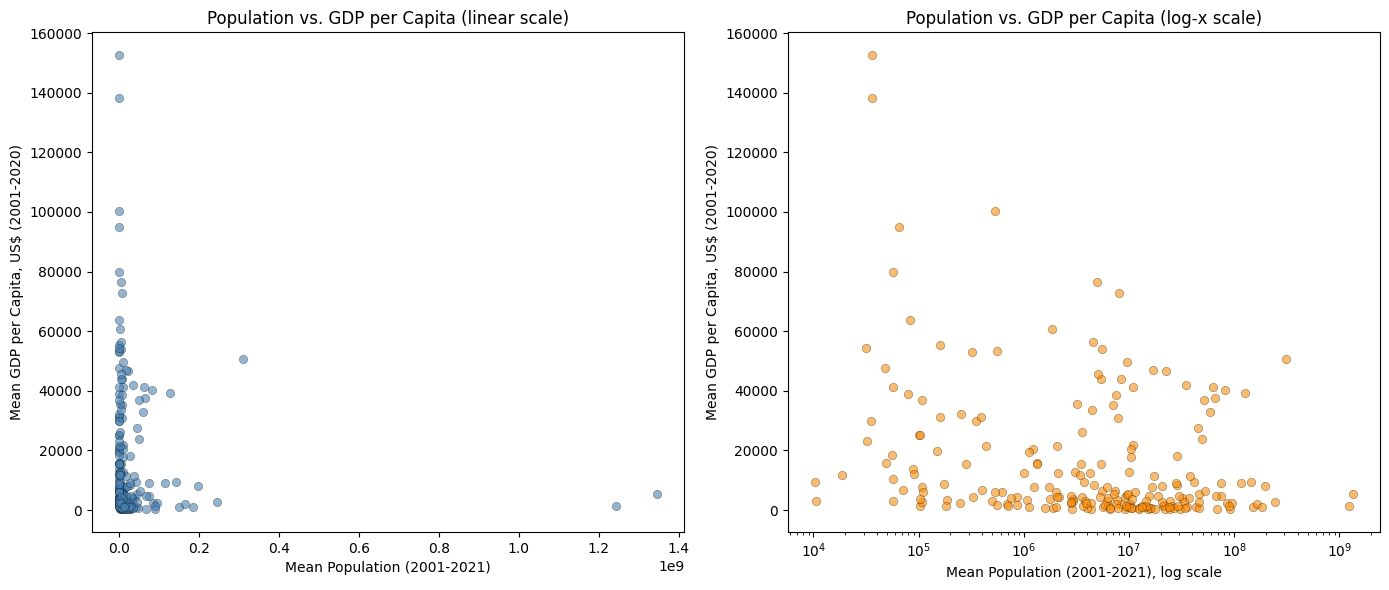

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df['mean_population'], df['mean_gdp_per_capita'], alpha=0.6, color='steelblue', edgecolor='k', linewidth=0.3)
axes[0].set_xlabel('Mean Population (2001-2021)')
axes[0].set_ylabel('Mean GDP per Capita, US$ (2001-2020)')
axes[0].set_title('Population vs. GDP per Capita (linear scale)')

axes[1].scatter(df['mean_population'], df['mean_gdp_per_capita'], alpha=0.6, color='darkorange', edgecolor='k', linewidth=0.3)
axes[1].set_xscale('log')
axes[1].set_xlabel('Mean Population (2001-2021), log scale')
axes[1].set_ylabel('Mean GDP per Capita, US$ (2001-2020)')
axes[1].set_title('Population vs. GDP per Capita (log-x scale)')

plt.tight_layout()
plt.show()

**Interpretation:** The points are scattered with no clear upward or downward trend, even on the log-population plot. Very populous countries (e.g. China, India, USA, Indonesia) appear across the full range of per‑capita GDP, and many of the richest countries per capita (e.g. small European or Gulf states) have small populations. This suggests population size alone is **not a strong predictor** of a country's average wealth per person.

In [12]:
pearson_r, pearson_p = stats.pearsonr(df['mean_population'], df['mean_gdp_per_capita'])

print(f'Pearson correlation coefficient (r): {pearson_r:.4f}')
print(f'P-value: {pearson_p:.4f}')
print(f'N (countries): {len(df)}')

Pearson correlation coefficient (r): -0.0686
P-value: 0.3192
N (countries): 213


**Result:** The Pearson correlation coefficient is very close to zero (small in magnitude, and not statistically significant at the 5% level), confirming the visual impression from the scatter plot — there is essentially **no linear correlation** between a country's mean population and its mean GDP per capita over 2001–2021. A country's wealth per person is driven far more by factors such as industrial structure, natural resources, institutions and trade than by the sheer number of people living there.

### **Task B — Linear Regression**

We fit a simple linear regression model:

$$\text{Mean GDP per Capita} = \beta_0 + \beta_1 \times \text{Mean Population} + \varepsilon$$

where **Mean Population** (2001–2021) is the independent variable (X) and **Mean GDP per Capita** (2001–2020) is the dependent variable (y).

In [13]:
X = df[['mean_population']].values
y = df['mean_gdp_per_capita'].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)
rmse = mean_squared_error(y, y_pred) ** 0.5

print(f'Slope (beta_1):      {slope:.10f}')
print(f'Intercept (beta_0):  {intercept:,.2f}')
print(f'R-squared:           {r2:.4f}')
print(f'RMSE:                {rmse:,.2f}')
print(f'\nRegression equation: GDP_per_capita = {intercept:,.2f} + ({slope:.6f}) * Population')

Slope (beta_1):      -0.0000120704
Intercept (beta_0):  16,054.16
R-squared:           0.0047
RMSE:                22,767.88

Regression equation: GDP_per_capita = 16,054.16 + (-0.000012) * Population


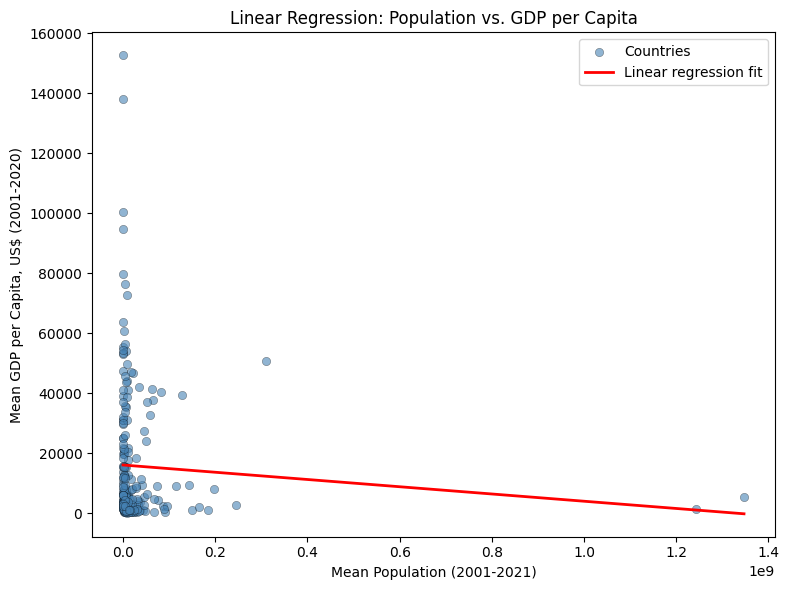

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(df['mean_population'], df['mean_gdp_per_capita'], alpha=0.6, color='steelblue',
            edgecolor='k', linewidth=0.3, label='Countries')

x_line = np.linspace(df['mean_population'].min(), df['mean_population'].max(), 200)
y_line = model.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2, label='Linear regression fit')

plt.xlabel('Mean Population (2001-2021)')
plt.ylabel('Mean GDP per Capita, US$ (2001-2020)')
plt.title('Linear Regression: Population vs. GDP per Capita')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The fitted line is almost flat and the **R² is close to 0**, meaning mean population explains almost none of the variation in mean GDP per capita across countries. This is consistent with the Task A finding: population size, by itself, has essentially no linear (positive or negative) relationship with a country's average wealth per person. A simple linear model using population alone is **not a useful predictor** of per‑capita GDP; a more complete model would need additional variables (e.g. capital investment, education, natural resources, governance quality).